In [1]:
import pandas as pd
df  = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


<Axes: xlabel='charges', ylabel='Count'>

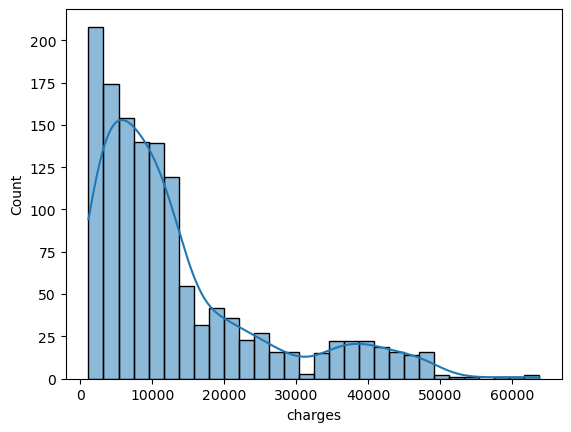

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df.charges, kde = True) # Before Transform

In [4]:
# Box-Cow on positive BMI
from scipy.stats import boxcox
df['bmi_boxcow'], _ = boxcox(df['bmi']+1)

<Axes: xlabel='log_charges', ylabel='Count'>

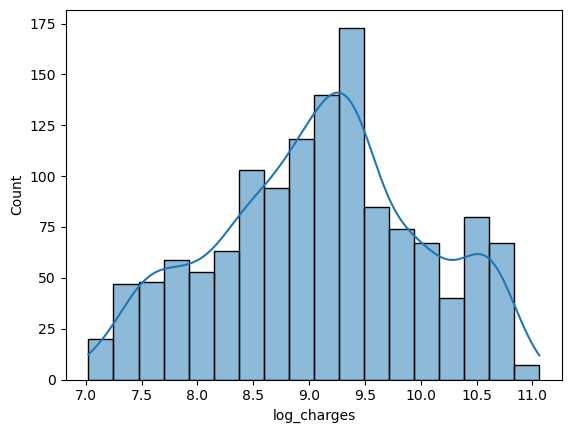

In [5]:
df['log_charges'] = np.log1p(df.charges)
sns.histplot(df['log_charges'], kde = True) # After transform

In [6]:
df.shape

(1338, 9)

# Feature Engineering

In [7]:
# Before applying Feature Engineering
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcow,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455


In [8]:
# Creating category as per bmi and age

In [9]:
df['bmi_cat'] = pd.cut(df.bmi, bins= [0,18.5,25,30,100], labels= ['under','normal','over','obese'])
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcow,log_charges,bmi_cat
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236,over
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882,obese
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763,obese
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137,normal
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455,over


In [10]:
df['bmi_age'] = pd.cut(df.age, bins= [17,30,45,60,100], labels= ['young','adult','mature','senior'])
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcow,log_charges,bmi_cat,bmi_age
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236,over,young
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882,obese,young
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763,obese,young
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137,normal,adult
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455,over,adult


In [11]:
df['age_smoker'] = df.age * (df.smoker=='yes')
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcow,log_charges,bmi_cat,bmi_age,age_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236,over,young,19
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882,obese,young,0
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763,obese,young,0
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137,normal,adult,0
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455,over,adult,0


# Data Distribution Analysis

<Axes: xlabel='bmi_boxcow', ylabel='Count'>

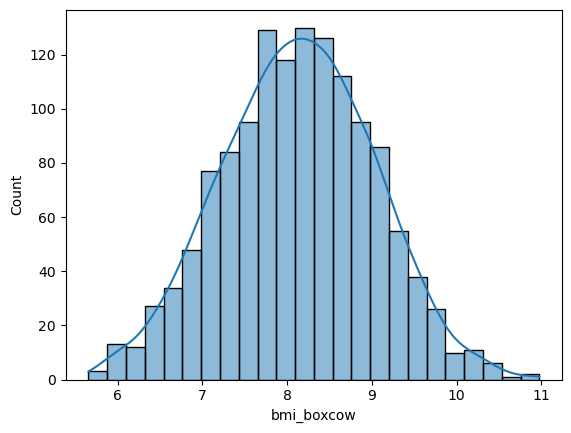

In [12]:
# Distribution plot
sns.histplot(df.bmi_boxcow,kde=True)

<Axes: xlabel='log_charges', ylabel='Count'>

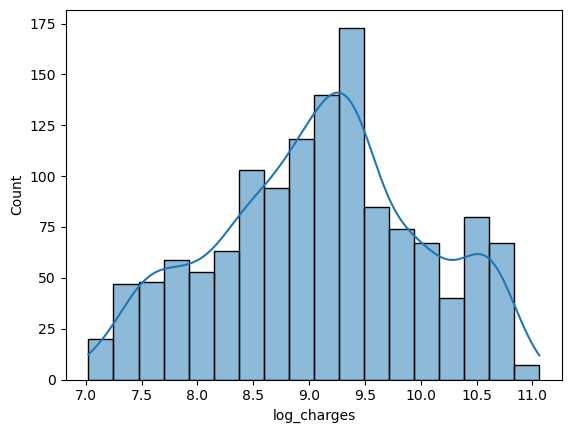

In [13]:
sns.histplot(df.log_charges,kde=True)

<Axes: xlabel='bmi_cat', ylabel='charges'>

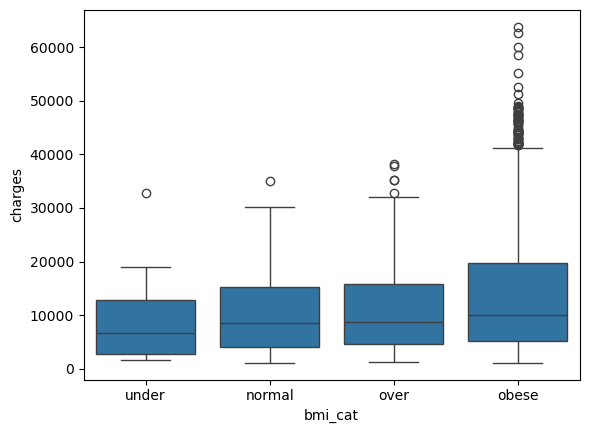

In [14]:
# Boxplot  for categorical  distribution
sns.boxplot(x='bmi_cat', y = 'charges', data =df)

<Axes: xlabel='smoker', ylabel='charges'>

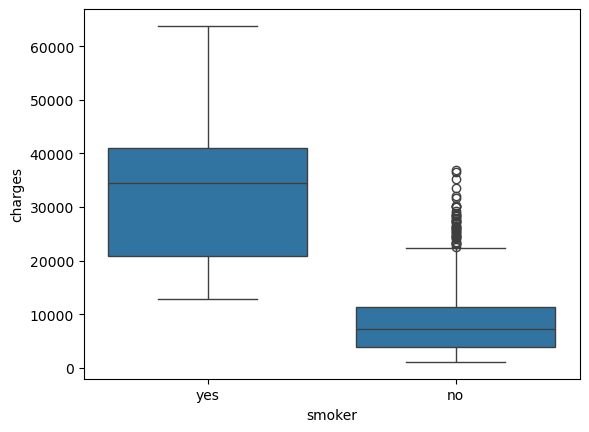

In [15]:
sns.boxplot(x='smoker', y = 'charges', data =df)

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_boxcow,log_charges,bmi_cat,bmi_age,age_smoker
0,19,female,27.900,0,yes,southwest,16884.92400,7.763291,9.734236,over,young,19
1,18,male,33.770,1,no,southeast,1725.55230,8.618976,7.453882,obese,young,0
2,28,male,33.000,3,no,southeast,4449.46200,8.511576,8.400763,obese,young,0
3,33,male,22.705,0,no,northwest,21984.47061,6.920914,9.998137,normal,adult,0
4,32,male,28.880,0,no,northwest,3866.85520,7.912470,8.260455,over,adult,0


<Axes: >

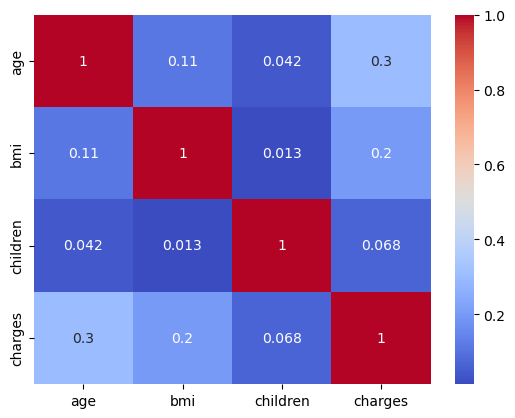

In [17]:
num_cols = ['age','bmi','children','charges']
corr = df[num_cols].corr()
sns.heatmap(corr,annot = True,cmap= 'coolwarm')

## Checking unique values for categorical fields

In [21]:
for col in ['sex','smoker','region','bmi_cat','bmi_age']:
    print(col,df[col].value_counts())
    print()

sex sex
male      676
female    662
Name: count, dtype: int64

smoker smoker
no     1064
yes     274
Name: count, dtype: int64

region region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

bmi_cat bmi_cat
obese     705
over      386
normal    226
under      21
Name: count, dtype: int64

bmi_age bmi_age
young     444
mature    409
adult     394
senior     91
Name: count, dtype: int64



## Target Variable Distribution

<Axes: xlabel='charges', ylabel='Count'>

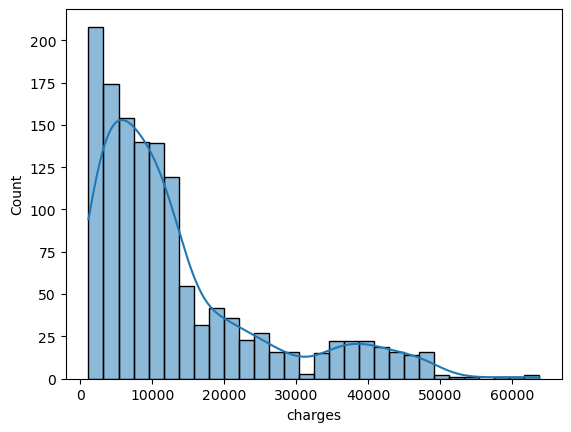

In [22]:
sns.histplot(df.charges,kde=True)